In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fact = pd.read_csv("fact_trips.csv")
stations = pd.read_csv("dim_stations.csv")
buses = pd.read_csv("dim_buses.csv")
routes = pd.read_csv("dim_routes.csv")
dates = pd.read_csv("dim_dates.csv")

In [19]:
df = fact.merge(stations, on="station_id") \
         .merge(buses, on="bus_id") \
         .merge(routes, on="route_id") \
         .merge(dates, on="date_id")

In [20]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           6000 non-null   int64  
 1   date_id           6000 non-null   int64  
 2   bus_id            6000 non-null   int64  
 3   route_id          6000 non-null   int64  
 4   station_id        6000 non-null   int64  
 5   passengers        6000 non-null   int64  
 6   revenue           6000 non-null   float64
 7   fuel_cost         6000 non-null   float64
 8   delay_min         6000 non-null   int64  
 9   cancellations     6000 non-null   int64  
 10  occupancy_rate    6000 non-null   float64
 11  ticket_price_avg  6000 non-null   float64
 12  profit            6000 non-null   float64
 13  weather           6000 non-null   object 
 14  traffic_level     6000 non-null   object 
 15  festival_flag     6000 non-null   int64  
 16  station_name      6000 non-null   object 


trip_id             0
date_id             0
bus_id              0
route_id            0
station_id          0
passengers          0
revenue             0
fuel_cost           0
delay_min           0
cancellations       0
occupancy_rate      0
ticket_price_avg    0
profit              0
weather             0
traffic_level       0
festival_flag       0
station_name        0
city                0
state               0
zone                0
capacity            0
bus_type            0
operator            0
seats               0
fuel_type           0
rating              0
source              0
destination         0
distance_km         0
duration_hr         0
date                0
day                 0
month               0
year                0
weekday             0
dtype: int64

In [22]:
# Remove null values
df = df.dropna()

# Remove zero or invalid values
df = df[(df['passengers'] > 0) & (df['revenue'] > 0)]

# Convert date column
df['date'] = pd.to_datetime(df['date'])

In [23]:
df['profit_margin'] = df['profit'] / df['revenue']
df['revenue_per_passenger'] = df['revenue'] / df['passengers']

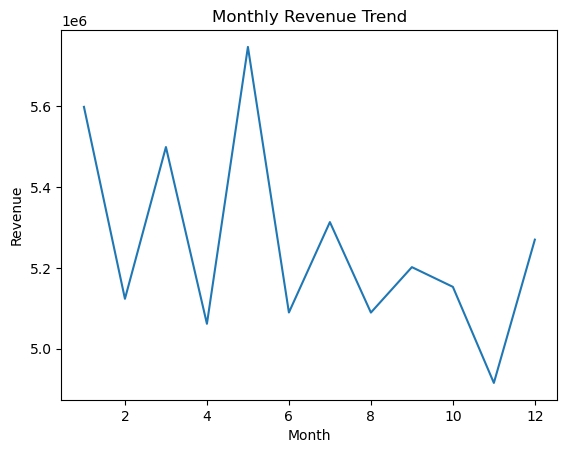

In [24]:
df.groupby('month')['revenue'].sum().plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

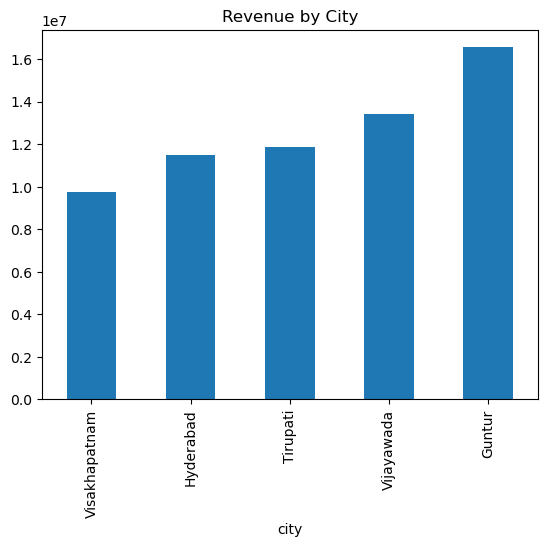

In [25]:
df.groupby('city')['revenue'].sum().sort_values().plot(kind='bar')
plt.title("Revenue by City")
plt.show()

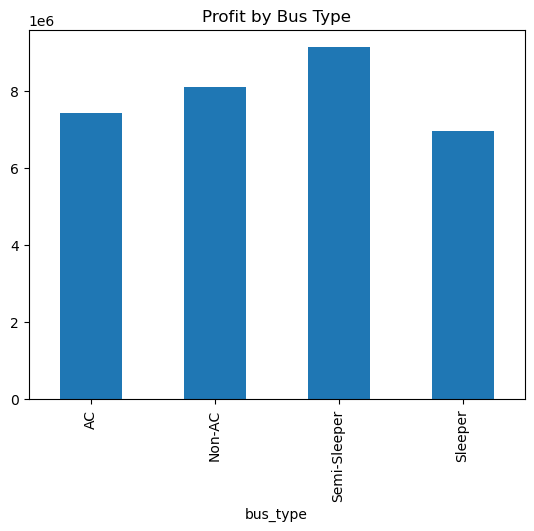

In [26]:
df.groupby('bus_type')['profit'].sum().plot(kind='bar')
plt.title("Profit by Bus Type")
plt.show()

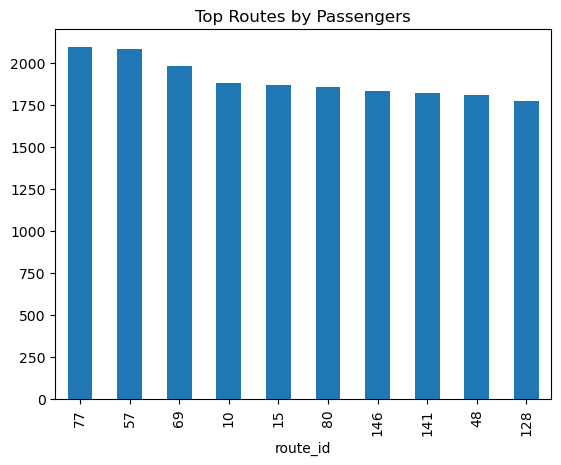

In [27]:
df.groupby('route_id')['passengers'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Routes by Passengers")
plt.show()

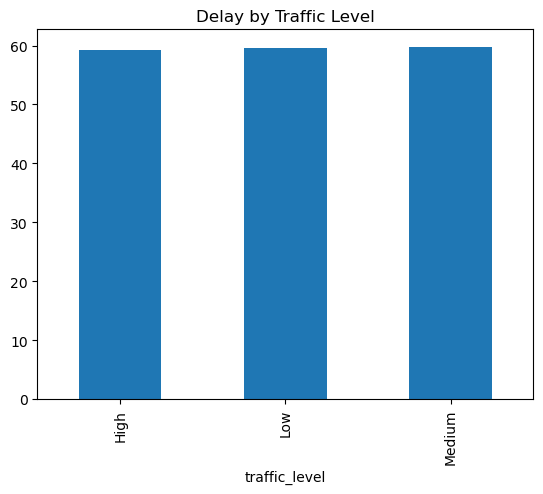

In [28]:
df.groupby('traffic_level')['delay_min'].mean().plot(kind='bar')
plt.title("Delay by Traffic Level")
plt.show()

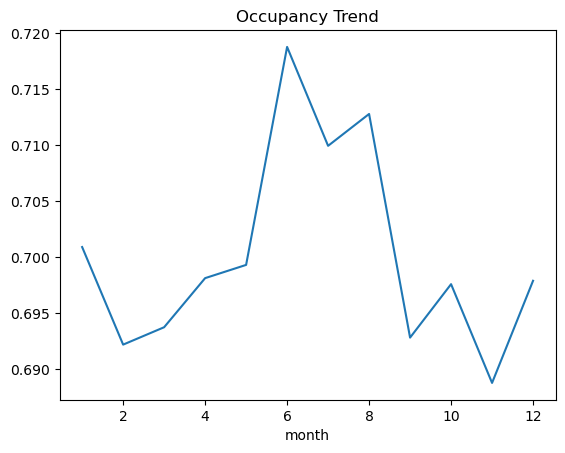

In [29]:
df.groupby('month')['occupancy_rate'].mean().plot()
plt.title("Occupancy Trend")
plt.show()

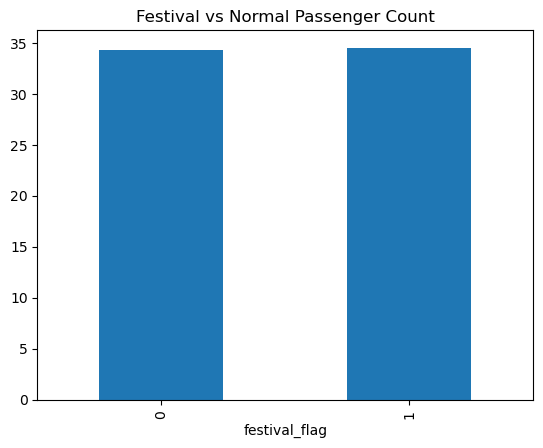

In [30]:
df.groupby('festival_flag')['passengers'].mean().plot(kind='bar')
plt.title("Festival vs Normal Passenger Count")
plt.show()

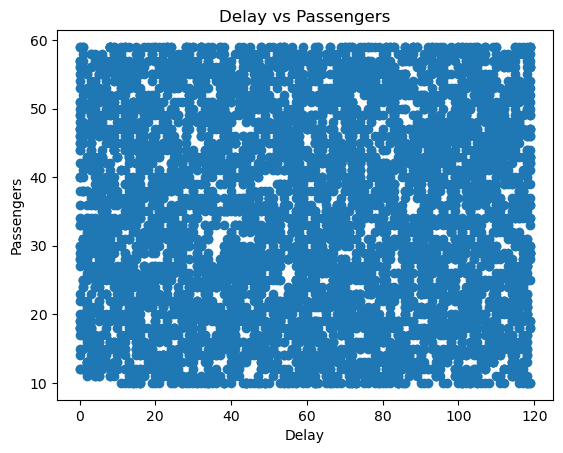

In [31]:
plt.scatter(df['delay_min'], df['passengers'])
plt.xlabel("Delay")
plt.ylabel("Passengers")
plt.title("Delay vs Passengers")
plt.show()

In [32]:
print("Total Revenue:", df['revenue'].sum())
print("Total Profit:", df['profit'].sum())
print("Avg Occupancy:", df['occupancy_rate'].mean())
print("Total Passengers:", df['passengers'].sum())

Total Revenue: 63061403.76
Total Profit: 31605217.78
Avg Occupancy: 0.7002233333333333
Total Passengers: 206362


In [33]:
revenue_data = df.groupby('bus_type')['revenue'].sum()

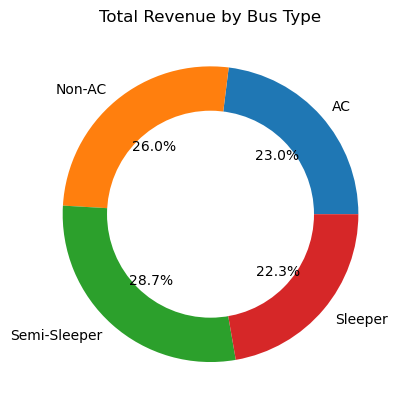

In [34]:
plt.figure()

plt.pie(revenue_data, labels=revenue_data.index, autopct='%1.1f%%')

# Create donut shape
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Total Revenue by Bus Type")
plt.show()

In [ ]:
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q')
df['month'] = df['date'].dt.to_period('M')
df['day'] = df['date'].dt.date

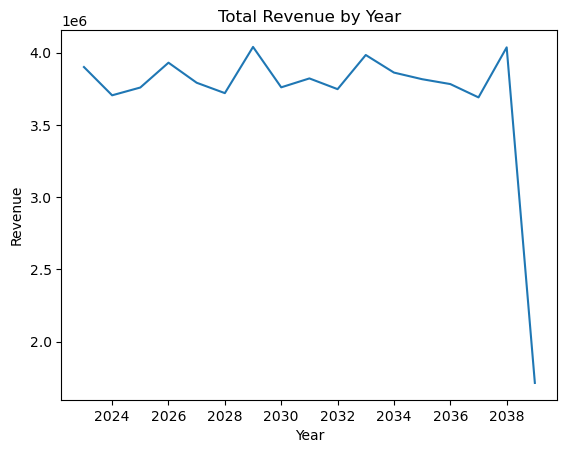

In [43]:
yearly = df.groupby('year')['revenue'].sum()

plt.figure()
yearly.plot()
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

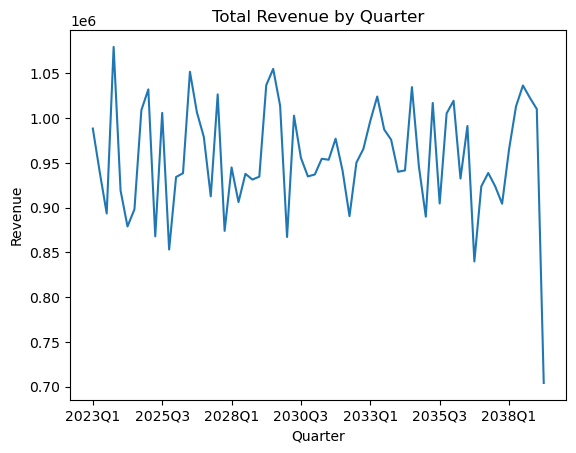

In [44]:
quarterly = df.groupby('quarter')['revenue'].sum()

plt.figure()
quarterly.plot()
plt.title("Total Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.show()

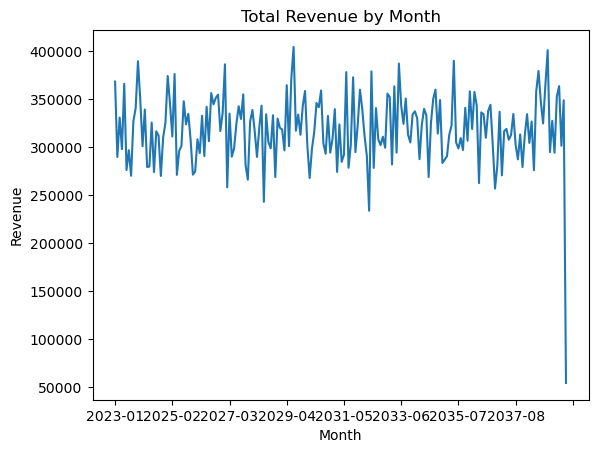

In [45]:
monthly = df.groupby('month')['revenue'].sum()

plt.figure()
monthly.plot()
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [51]:
pivot = df.groupby(['route_id', 'operator'])['station_id'].count().unstack()

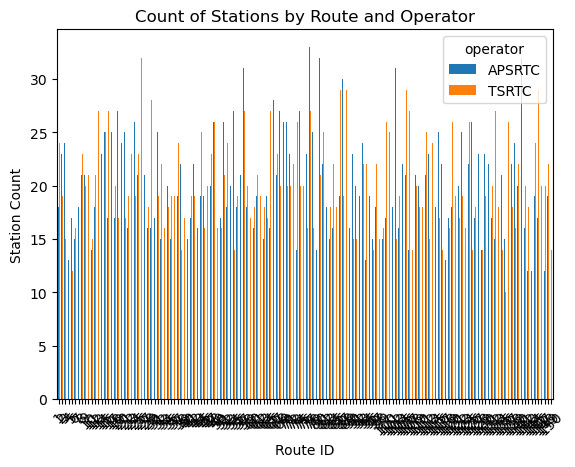

In [52]:
pivot.plot(kind='bar')

plt.title("Count of Stations by Route and Operator")
plt.xlabel("Route ID")
plt.ylabel("Station Count")
plt.xticks(rotation=45)

plt.show()

In [53]:
profit_data = df.groupby('city')['profit'].sum().sort_values()

In [54]:
cumulative = profit_data.cumsum()

# Shift cumulative for base positions
base = cumulative.shift(fill_value=0)

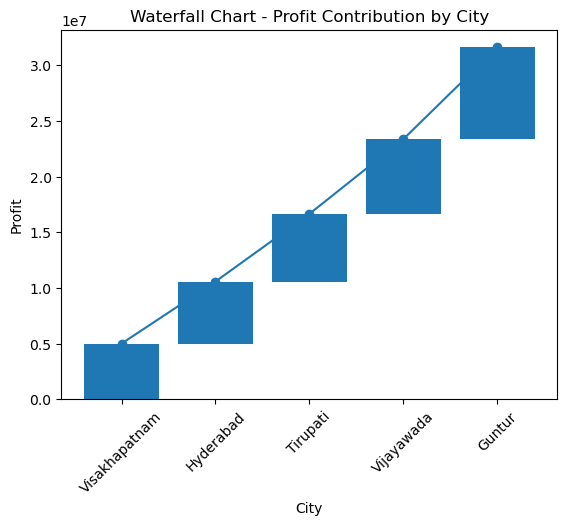

In [55]:
plt.figure()

# Bars
plt.bar(profit_data.index, profit_data, bottom=base)

# Line showing cumulative progression
plt.plot(profit_data.index, cumulative, marker='o')

plt.title("Waterfall Chart - Profit Contribution by City")
plt.xlabel("City")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()

In [57]:
df['month'] = df['date'].dt.to_period('M').astype(str)

In [58]:
pivot = df.groupby(['month', 'station_name'])['passengers'].sum().unstack()

In [59]:
top_stations = df.groupby('station_name')['passengers'].sum().nlargest(5).index
pivot = pivot[top_stations]

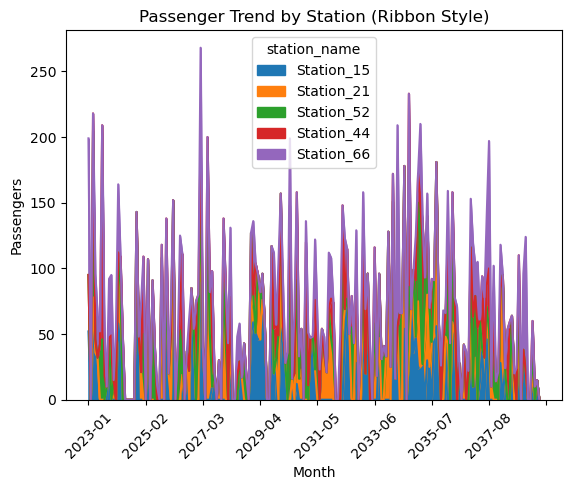

In [60]:
pivot.plot.area()

plt.title("Passenger Trend by Station (Ribbon Style)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.xticks(rotation=45)

plt.show()

In [62]:
zone_data = df.groupby('zone')['passengers'].sum().sort_values(ascending=False)

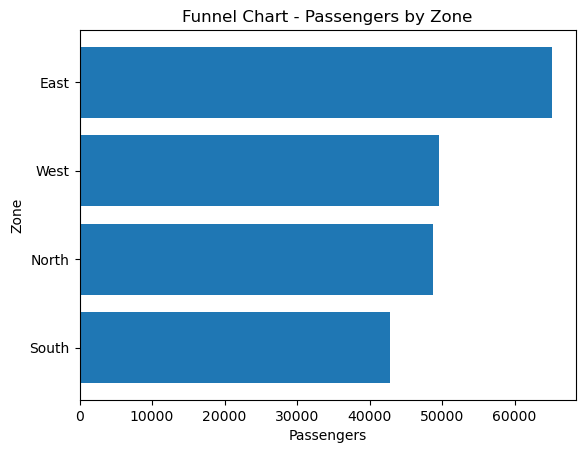

In [63]:
plt.figure()

# Horizontal bars (funnel style)
plt.barh(zone_data.index, zone_data.values)

# Reverse order for funnel effect (largest on top)
plt.gca().invert_yaxis()

plt.title("Funnel Chart - Passengers by Zone")
plt.xlabel("Passengers")
plt.ylabel("Zone")

plt.show()